# Scratch with Normal Equation 
Lets write Linear Regression from scratch using Normal Equation and compare it with sklearn's LinearRegression


In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

--- From Scratch Results ---
Intercept (theta_0): 4.107548
Slope (theta_1):     2.885057

--- Sklearn Results ---
Intercept (theta_0): 4.107548
Slope (theta_1):     2.885057



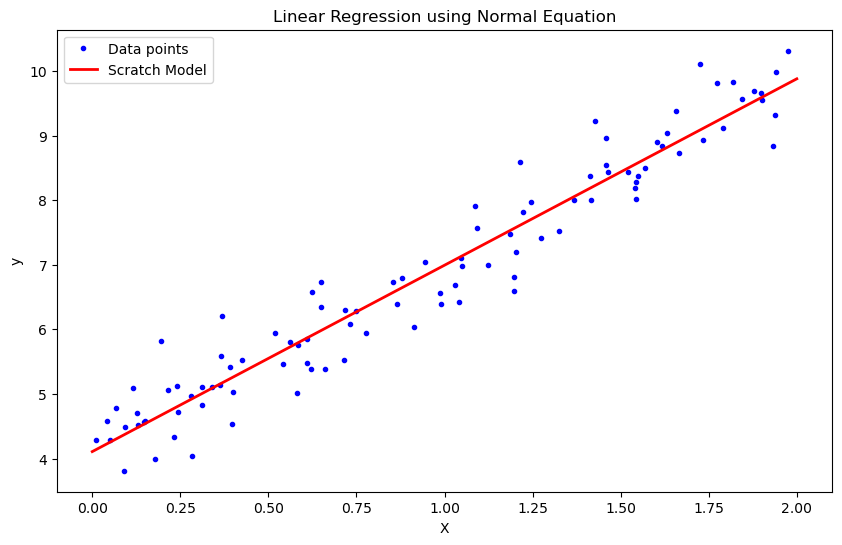

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LinearRegression


class LR_with_normal_equation:
    def __init__(self):
        self.theta = None
        self.intercept_ = None
        self.coef_ = None

    def fit(self, X, y):
        m = len(X)
        X_b = np.c_[np.ones((m, 1)), X] # adding bias

        self.theta = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y

        # extraction of intercept and coefficients for compatibility with sklearn
        self.intercept_ = self.theta[0]
        self.coef_ = self.theta[1:].ravel()

        return self

    def predict(self, X):
        m = len(X)
        X_b = np.c_[np.ones((m, 1)), X] # adding bias

        return X_b @ self.theta


if __name__ == "__main__":
    np.random.seed(42)
    X_data = 2 * np.random.rand(100, 1)
    y_data = 4 + 3 * X_data + np.random.randn(100, 1) * 0.5

    # scratch implementation
    scratch_model = LR_with_normal_equation()
    scratch_model.fit(X_data, y_data)
    print("--- From Scratch Results ---")
    print(f"Intercept (theta_0): {scratch_model.intercept_[0]:.6f}")
    print(f"Slope (theta_1):     {scratch_model.coef_[0]:.6f}\n")

    # sklearn implementation
    lr_sklearn = LinearRegression()
    lr_sklearn.fit(X_data, y_data)
    print("--- Sklearn Results ---")
    print(f"Intercept (theta_0): {lr_sklearn.intercept_[0]:.6f}")
    print(f"Slope (theta_1):     {lr_sklearn.coef_[0][0]:.6f}\n")


    ## Plotting the results
    X_new = np.array([[0], [2]])
    y_predict_scratch = scratch_model.predict(X_new)
    plt.figure(figsize=(10, 6))
    plt.plot(X_data, y_data, "b.", label="Data points")
    plt.plot(X_new, y_predict_scratch, "r-", linewidth=2, label="Scratch Model")
    plt.ylabel("y")
    plt.xlabel("X")
    plt.title("Linear Regression using Normal Equation")
    plt.legend()
    plt.show()
    